In [1]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

sc.set_figure_params(figsize=(5, 5))

In [4]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

In [10]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

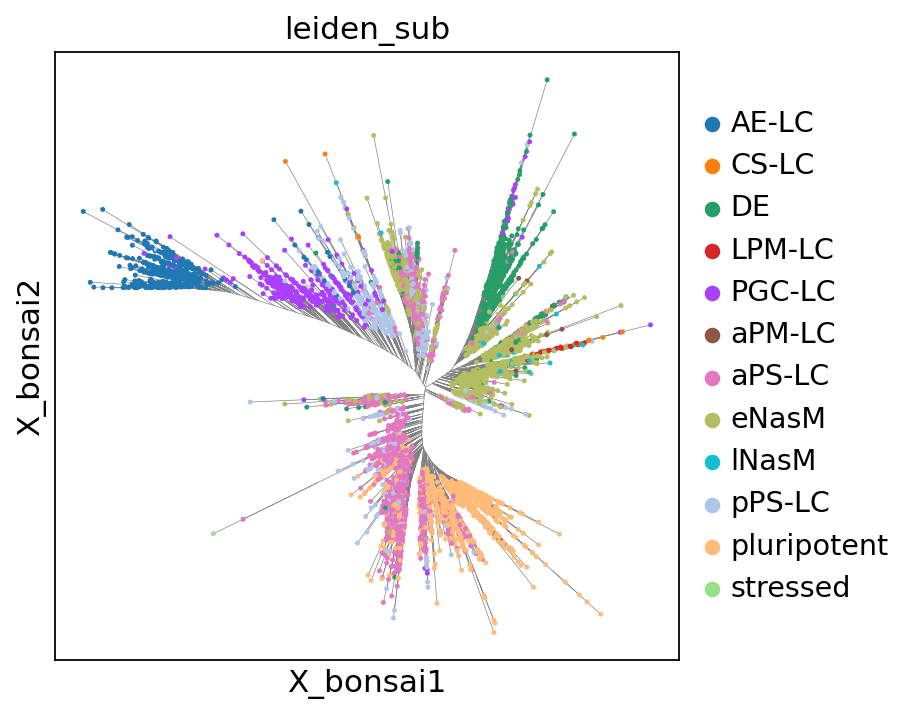

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
# optionally plot branch points
# ax.scatter(coords[int_inds, 0], coords[int_inds, 1], s=1, c="gray", alpha=0.5, zorder=2)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)
# plt.savefig(
#     "bonsai_micropattern_48h-1_circular_tree_view.png", dpi=300, bbox_inches="tight"
# )

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

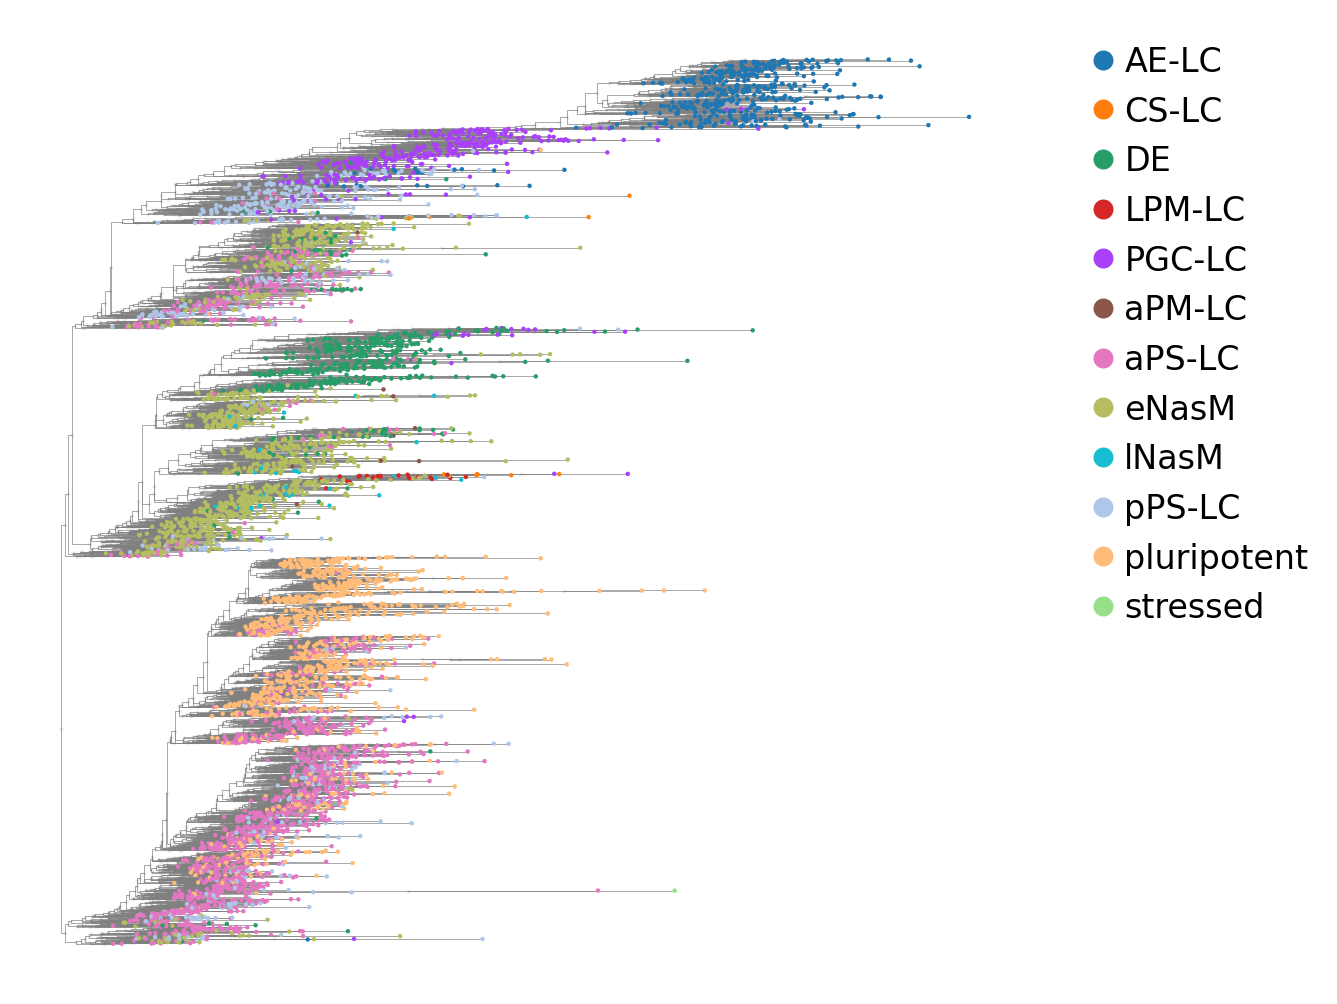

In [12]:
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
# plt.savefig("bonsai_micropattern_48h-1_rec_tree_view.png", dpi=300, bbox_inches="tight")

In [ ]:
# for web app
# adata.obs.to_csv(
#     "./heemskerk_data/adata_timeseries_old_48h-1_meta.csv", index_label="cellID"
# )

# Optimize tree

In [5]:
from my_tree_layout import Layout_Tree

node_id_to_vert_ind = {}
with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/vertInfo.txt") as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/tree.nwk") as f:
    nwk_str = f.read().strip()

ly_tree = Layout_Tree()
ly_tree.from_newick(nwk_str, node_id_to_vert_ind=node_id_to_vert_ind)
ly_tree.reset_root(node_id_to_vert_ind["internal_1924"])
ly_tree.equalAngle()
coords = ly_tree.coords.copy()

In [10]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")

In [14]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1_with_loop.h5ad")
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords

In [141]:
import micropattern as mic

adata.obs["in_loop_knn"] = (
    adata.obs["in_loop"].cat.add_categories("none").fillna("none")
)
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=40)
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pred_lab["in_loop_knn"]
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=50)
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pd.Categorical(pred_lab["in_loop_knn"])
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"
model = mic.knn.weighted_knn_trainer(adata, "X_diffmap", n_neighbors=30)
pred_lab, uncert = mic.knn.weighted_knn_transfer(
    adata,
    "X_diffmap",
    adata.obs.loc[:, ["sample_labels", "in_loop_knn"]],
    "in_loop_knn",
    model,
)
adata.obs["in_loop_knn"] = pd.Categorical(pred_lab["in_loop_knn"]).remove_categories(
    "none"
)
adata.obs["in_loop_knn_uncert"] = uncert["in_loop_knn"]
adata.obs.loc[adata.obs["in_loop_knn_uncert"] > 0.01, "in_loop_knn"] = "PGC-DE"

Weighted KNN with n_neighbors = 40 ... 

/home/stan/Git/micropattern/src/micropattern/knn.py:140: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = max(1 - best_prob, 0)
/home/stan/Git/micropattern/src/micropattern/knn.py:145: FutureWarning: ChainedAssignment

finished!
Weighted KNN with n_neighbors = 50 ... 

/home/stan/Git/micropattern/src/micropattern/knn.py:140: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = max(1 - best_prob, 0)
/home/stan/Git/micropattern/src/micropattern/knn.py:145: FutureWarning: ChainedAssignment

finished!
Weighted KNN with n_neighbors = 30 ... finished!


/home/stan/Git/micropattern/src/micropattern/knn.py:140: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  uncertainties.iloc[i][j] = max(1 - best_prob, 0)
/home/stan/Git/micropattern/src/micropattern/knn.py:145: FutureWarning: ChainedAssignment

In [114]:
uncert["in_loop_knn"]

cellID
AAACCCAAGCAACAAT-1_48h         0.0
AAACCCAAGCCACTCG-1_48h         0.0
AAACCCAAGGACTAAT-1_48h    0.266667
AAACCCACACAAATAG-1_48h         0.0
AAACCCACACAGAGCA-1_48h    0.066667
                            ...   
TTTGTTGAGCGGACAT-1_48h         0.0
TTTGTTGAGTACGTCT-1_48h           0
TTTGTTGCAAATGAGT-1_48h         0.0
TTTGTTGGTCGAGTGA-1_48h         0.0
TTTGTTGTCCATTTCA-1_48h         0.0
Name: in_loop_knn, Length: 5927, dtype: object

[<Axes: title={'center': 'in_loop_knn'}, xlabel='DC3', ylabel='DC4'>,
 <Axes: title={'center': 'in_loop_knn_uncert'}, xlabel='DC3', ylabel='DC4'>]

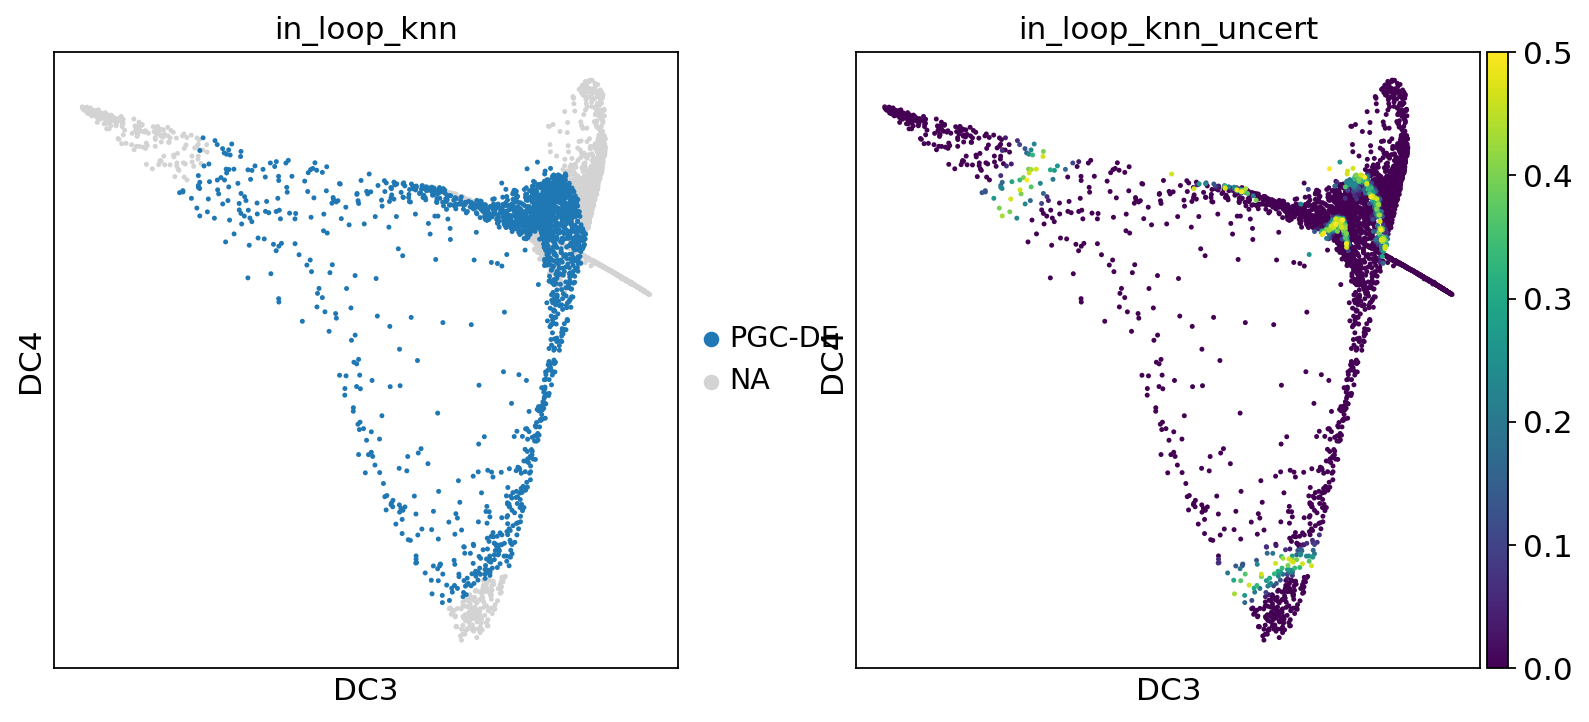

In [142]:
sc.pl.diffmap(
    adata,
    color=["in_loop_knn", "in_loop_knn_uncert"],
    s=20,
    show=False,
    components=["3,4"],
)

[<Axes: title={'center': 'in_loop_knn'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>,
 <Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>]

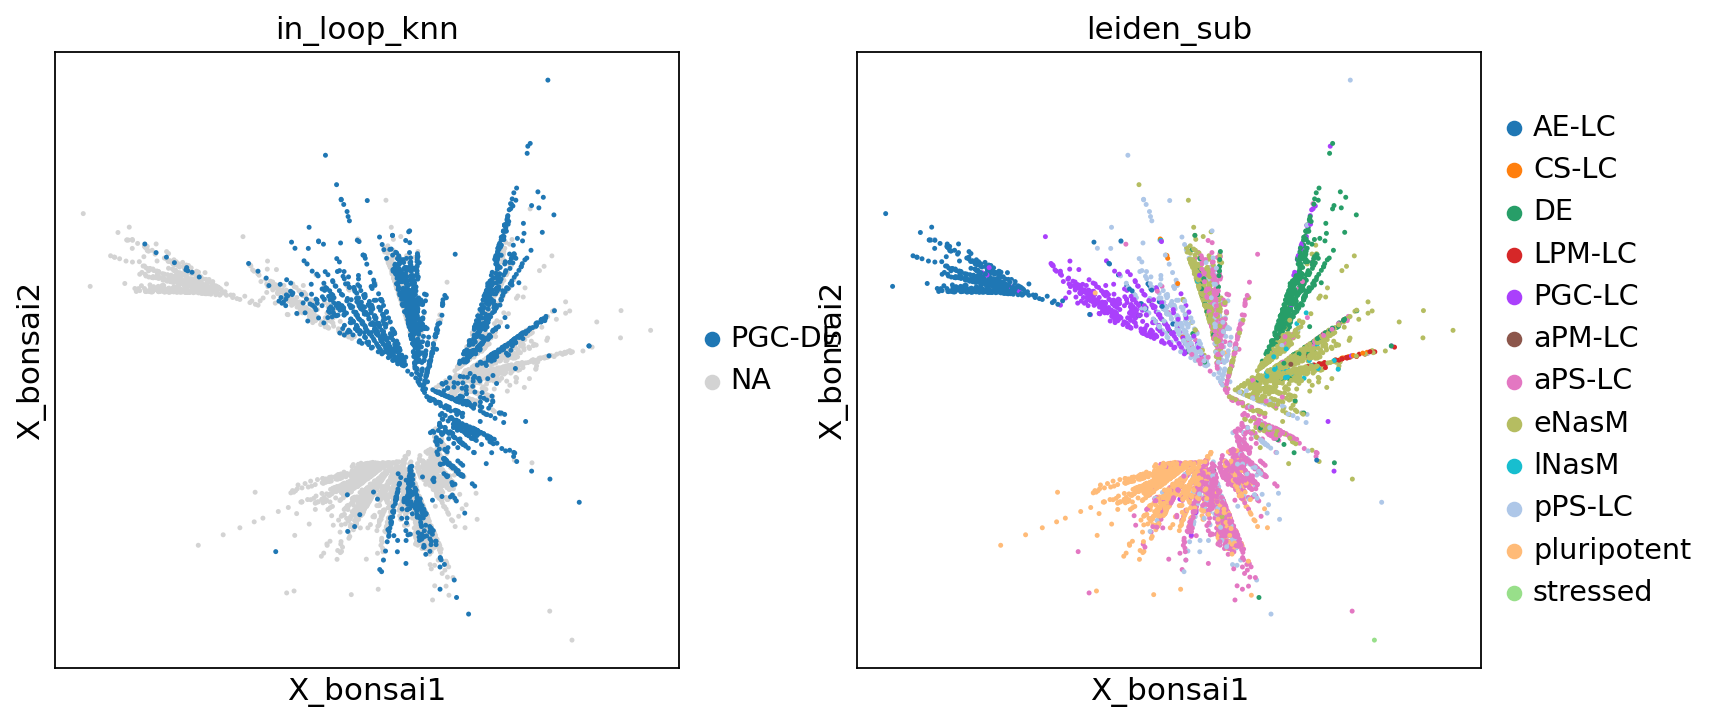

In [143]:
# fig, ax = plt.subplots(figsize=(5, 5))
# for e in edge_coords:
#     ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
# optionally plot branch points
# ax.scatter(coords[int_inds, 0], coords[int_inds, 1], s=1, c="gray", alpha=0.5, zorder=2)
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color=["in_loop_knn", "leiden_sub"],
    # ax=ax,
    show=False,
    s=20,
    zorder=2,
)

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

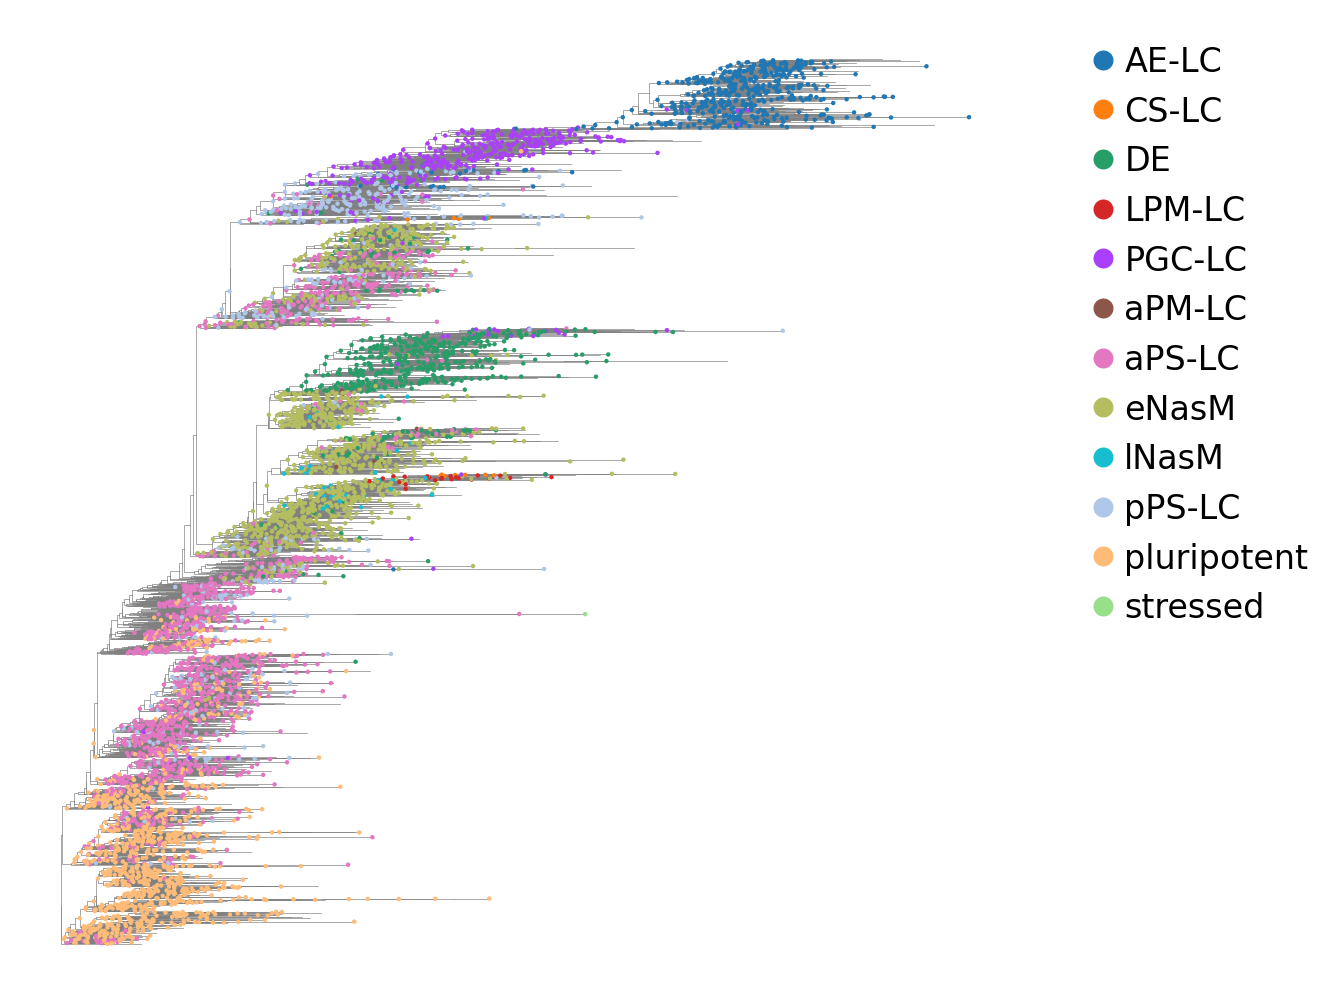

In [ ]:
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [145]:
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")

from downstream_analyses.get_clusters_max_diameter import (
    get_annotation_based_clustering_from_nwk_str,
    get_cluster_assignments,
)

annotation_dict = adata.obs["leiden_sub"].to_dict()

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/tree.nwk") as f:
    nwk_str = f.read().strip()
clusters, cut_edges, nmi = get_annotation_based_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, annotation_dict=annotation_dict, cutting_tol=0.005
)
cluster_dict = get_cluster_assignments({"annot": clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

03-18 18:11:03 mp_print INFO Annotation-based clustering has done 2 moves, currently 3 clusters, and Normalized Mutual Information of 0.5168597534963729.
03-18 18:11:03 mp_print INFO Annotation-based clustering has done 4 moves, currently 5 clusters, and Normalized Mutual Information of 0.5906816877586086.
03-18 18:11:03 mp_print INFO 
After making 8 clusters, norm. mutual information doesn't significantly increase. Stopping here.
03-18 18:11:03 mp_print INFO Final annotation-based clustering did 8 moves, created 8 clusters, with a Normalized Mutual Information of 0.6125171516544274.
03-18 18:11:03 mp_print INFO Clustering done


In [ ]:
adata.obs["bonsai_knn"] = adata.obs["bonsai_cluster"]

<Axes: title={'center': 'leiden_sub'}, xlabel='DC3', ylabel='DC4'>

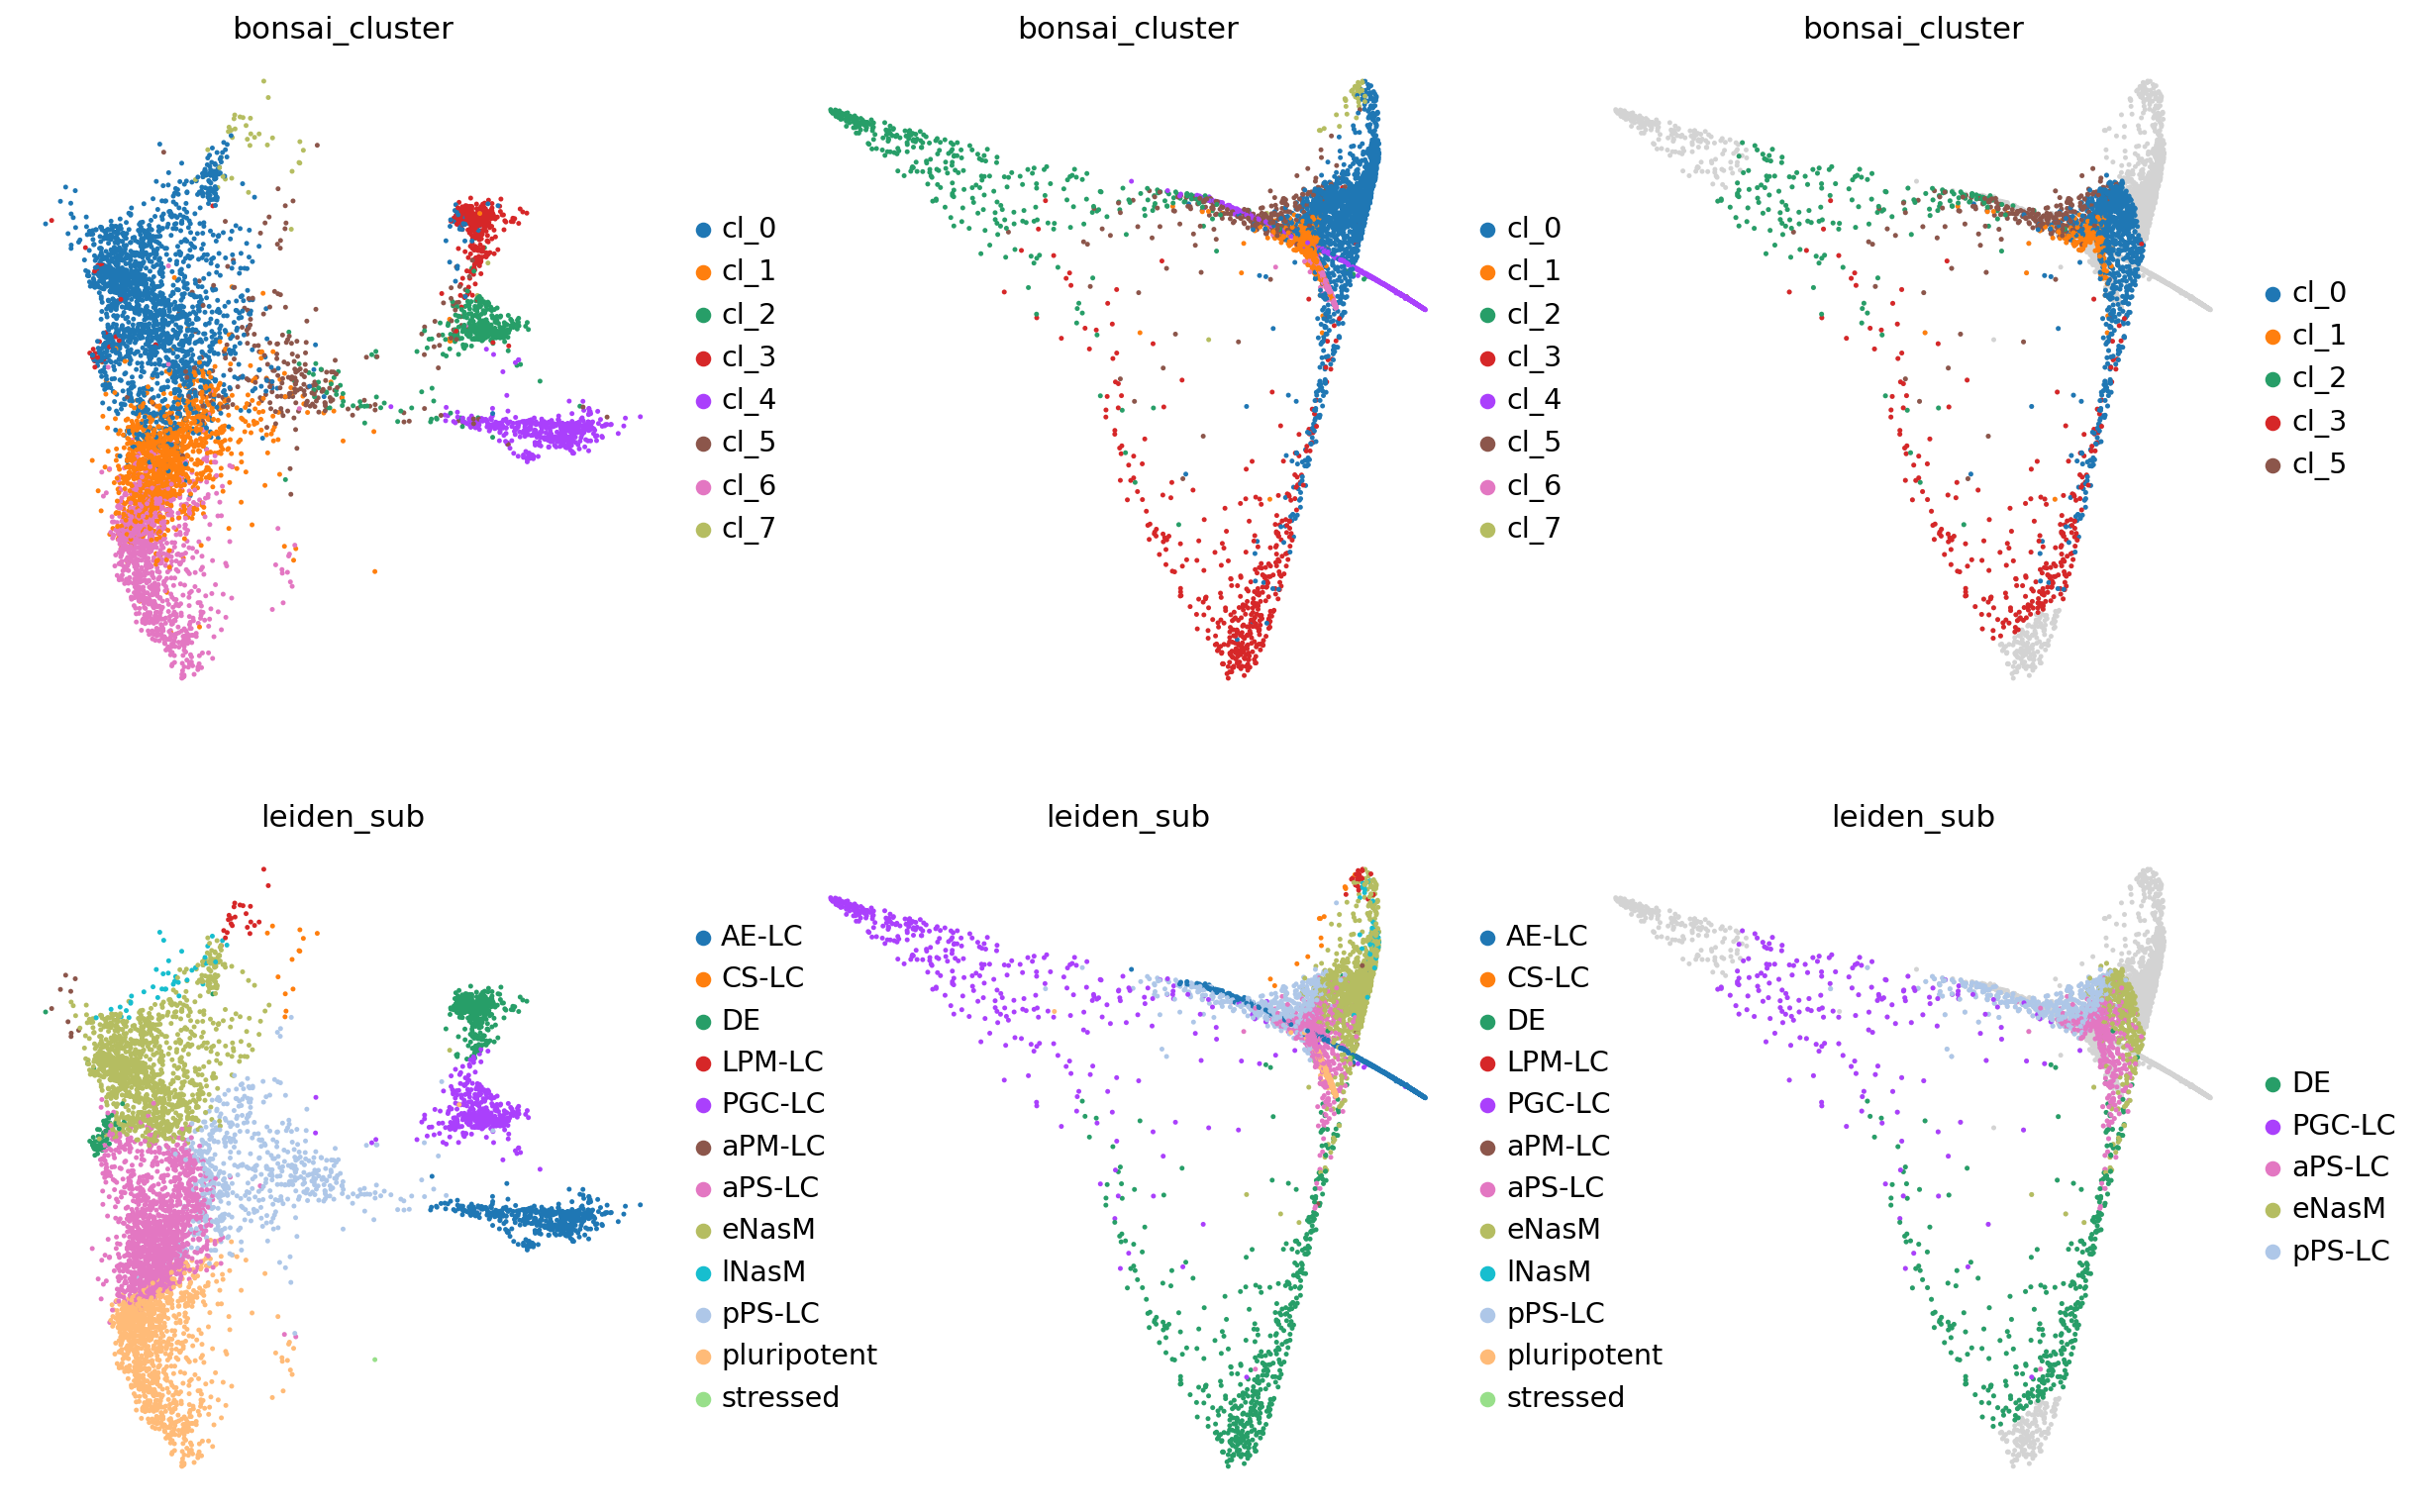

In [176]:
fig, axes = plt.subplots(2, 3, figsize=(24 * 0.75, 16 * 0.75))
adata_sub = adata[~pd.isna(adata.obs["in_loop_knn"])]
bonsai_counts = adata_sub.obs["bonsai_cluster"].value_counts()
min_counts = bonsai_counts.min() * 10
adata_sub = adata_sub[
    adata_sub.obs["bonsai_cluster"].map(bonsai_counts).astype(int) > min_counts
]
ax = axes[0, 0]
sc.pl.umap(
    adata,
    s=20,
    show=False,
    color="bonsai_cluster",
    ax=ax,
    frameon=False,
)
ax = axes[1, 0]
sc.pl.umap(
    adata,
    s=20,
    show=False,
    color="leiden_sub",
    ax=ax,
    frameon=False,
)
ax = axes[0, 1]
sc.pl.diffmap(
    adata,
    s=20,
    show=False,
    color="bonsai_cluster",
    components=["3,4"],
    ax=ax,
    frameon=False,
)
ax = axes[1, 1]
sc.pl.diffmap(
    adata,
    s=20,
    show=False,
    color="leiden_sub",
    components=["3,4"],
    ax=ax,
    frameon=False,
)
ax = axes[0, 2]
sc.pl.diffmap(adata, s=20, show=False, components=["3,4"], ax=ax)
sc.pl.diffmap(
    adata_sub,
    s=20,
    show=False,
    components=["3,4"],
    color="bonsai_cluster",
    ax=ax,
    frameon=False,
)
ax = axes[1, 2]
leiden_sub_counts = adata_sub.obs["leiden_sub"].value_counts()
min_leiden_sub_counts = leiden_sub_counts.min() * 10
adata_sub = adata_sub[
    adata_sub.obs["leiden_sub"].map(leiden_sub_counts).astype(int)
    > min_leiden_sub_counts
]
sc.pl.diffmap(adata, s=20, show=False, components=["3,4"], ax=ax)
sc.pl.diffmap(
    adata_sub,
    s=20,
    show=False,
    components=["3,4"],
    color="leiden_sub",
    ax=ax,
    frameon=False,
)

In [180]:
adata.obs["in_loop_knn_uncert"] = adata.obs["in_loop_knn_uncert"].astype(float)
adata.obs["bonsai_knn_uncert"] = adata.obs["bonsai_knn_uncert"].astype(float)
adata.write_h5ad(
    "./heemskerk_data/adata_timeseries_old_48h-1_with_loop_and_bonsai_cluster.h5ad"
)

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

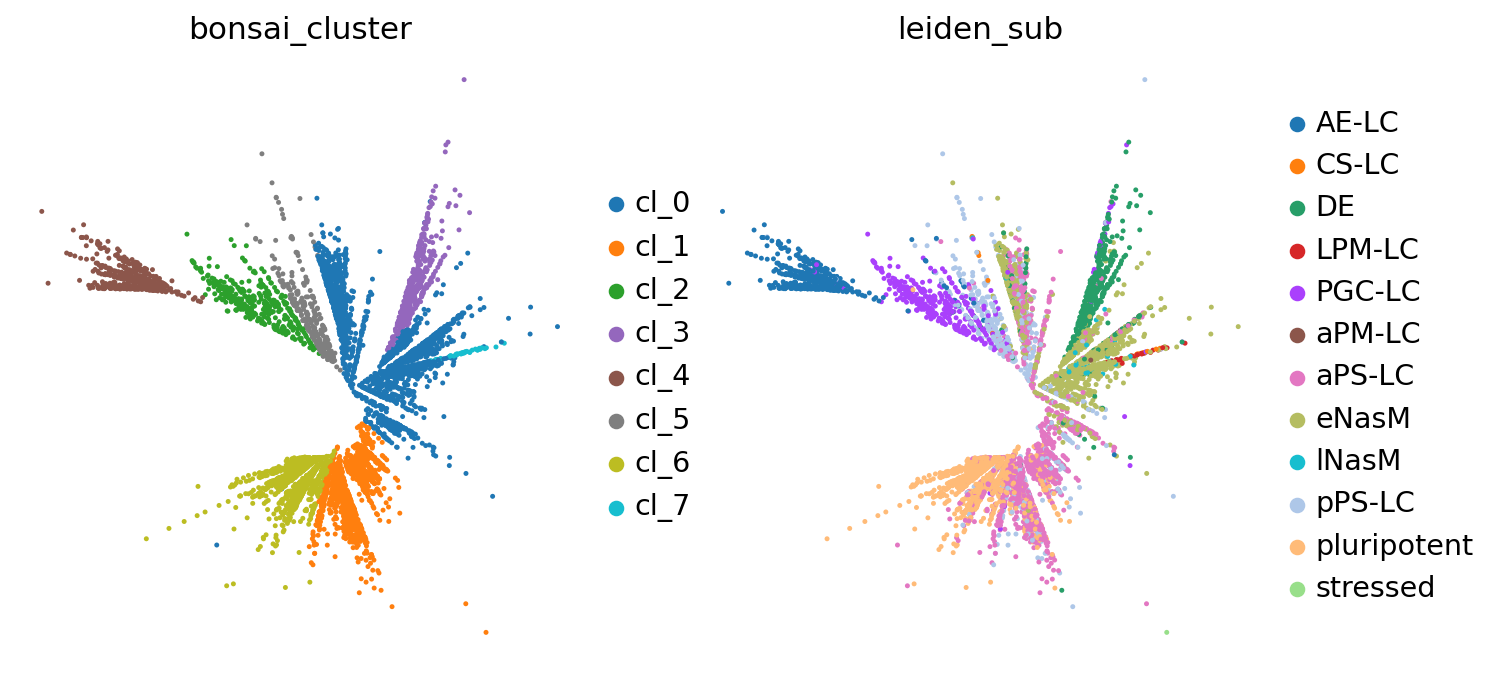

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="bonsai_cluster",
    ax=axes[0],
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="leiden_sub",
    ax=axes[1],
    show=False,
    s=20,
    frameon=False,
)

In [175]:
adata.obsm["X_umap"] = adata.obs.loc[
    :, ["umap_old_48-96h_x", "umap_old_48-96h_y"]
].values

<Axes: title={'center': 'leiden_sub'}, xlabel='UMAP1', ylabel='UMAP2'>

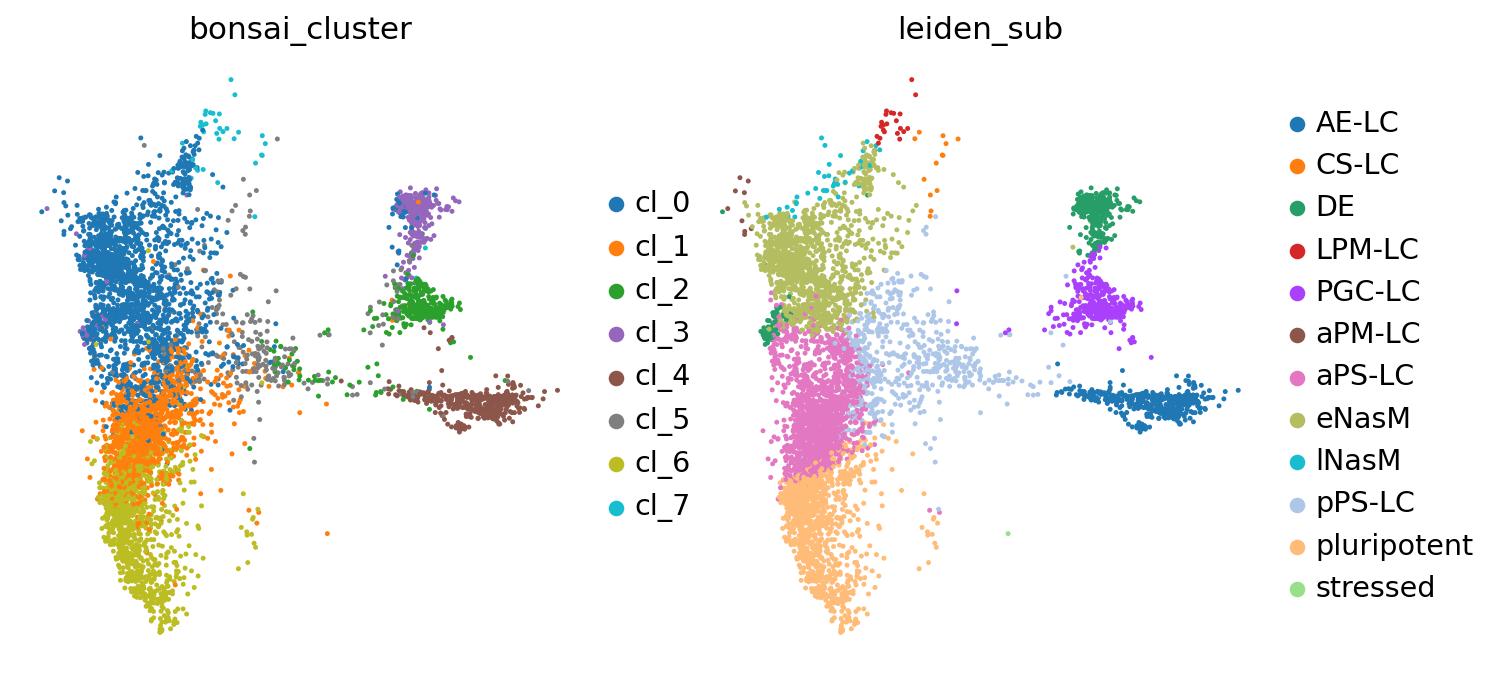

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(
    adata,
    color="bonsai_cluster",
    ax=axes[0],
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
sc.pl.umap(
    adata,
    color="leiden_sub",
    ax=axes[1],
    show=False,
    s=20,
    frameon=False,
)

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

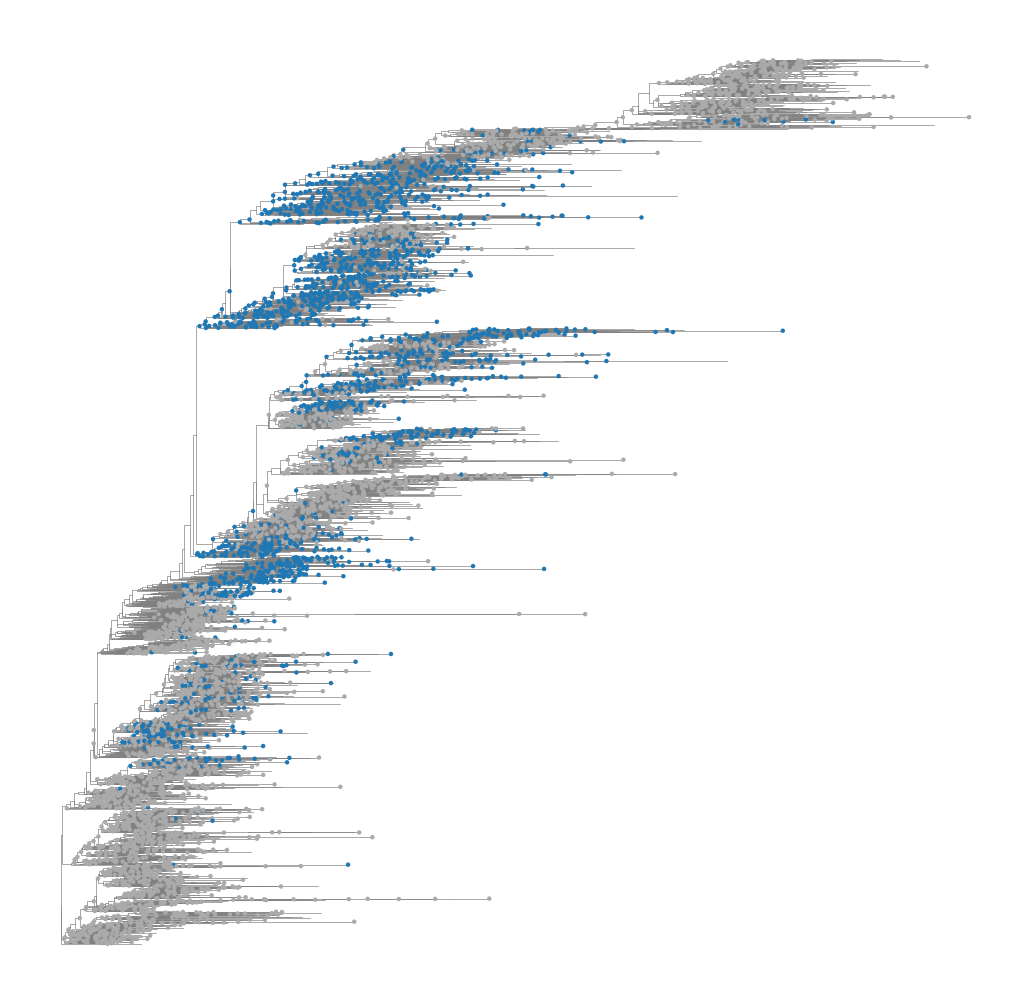

In [144]:
colors = adata.uns["in_loop_knn_colors"]
categories = adata.obs["in_loop_knn"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["in_loop_knn"].map(cat_to_color).values
cell_colors = [c if c is not np.nan else "#AAAAAA" for c in cell_colors]

fig, ax = plt.subplots(figsize=(8, 8))
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.axis("off")

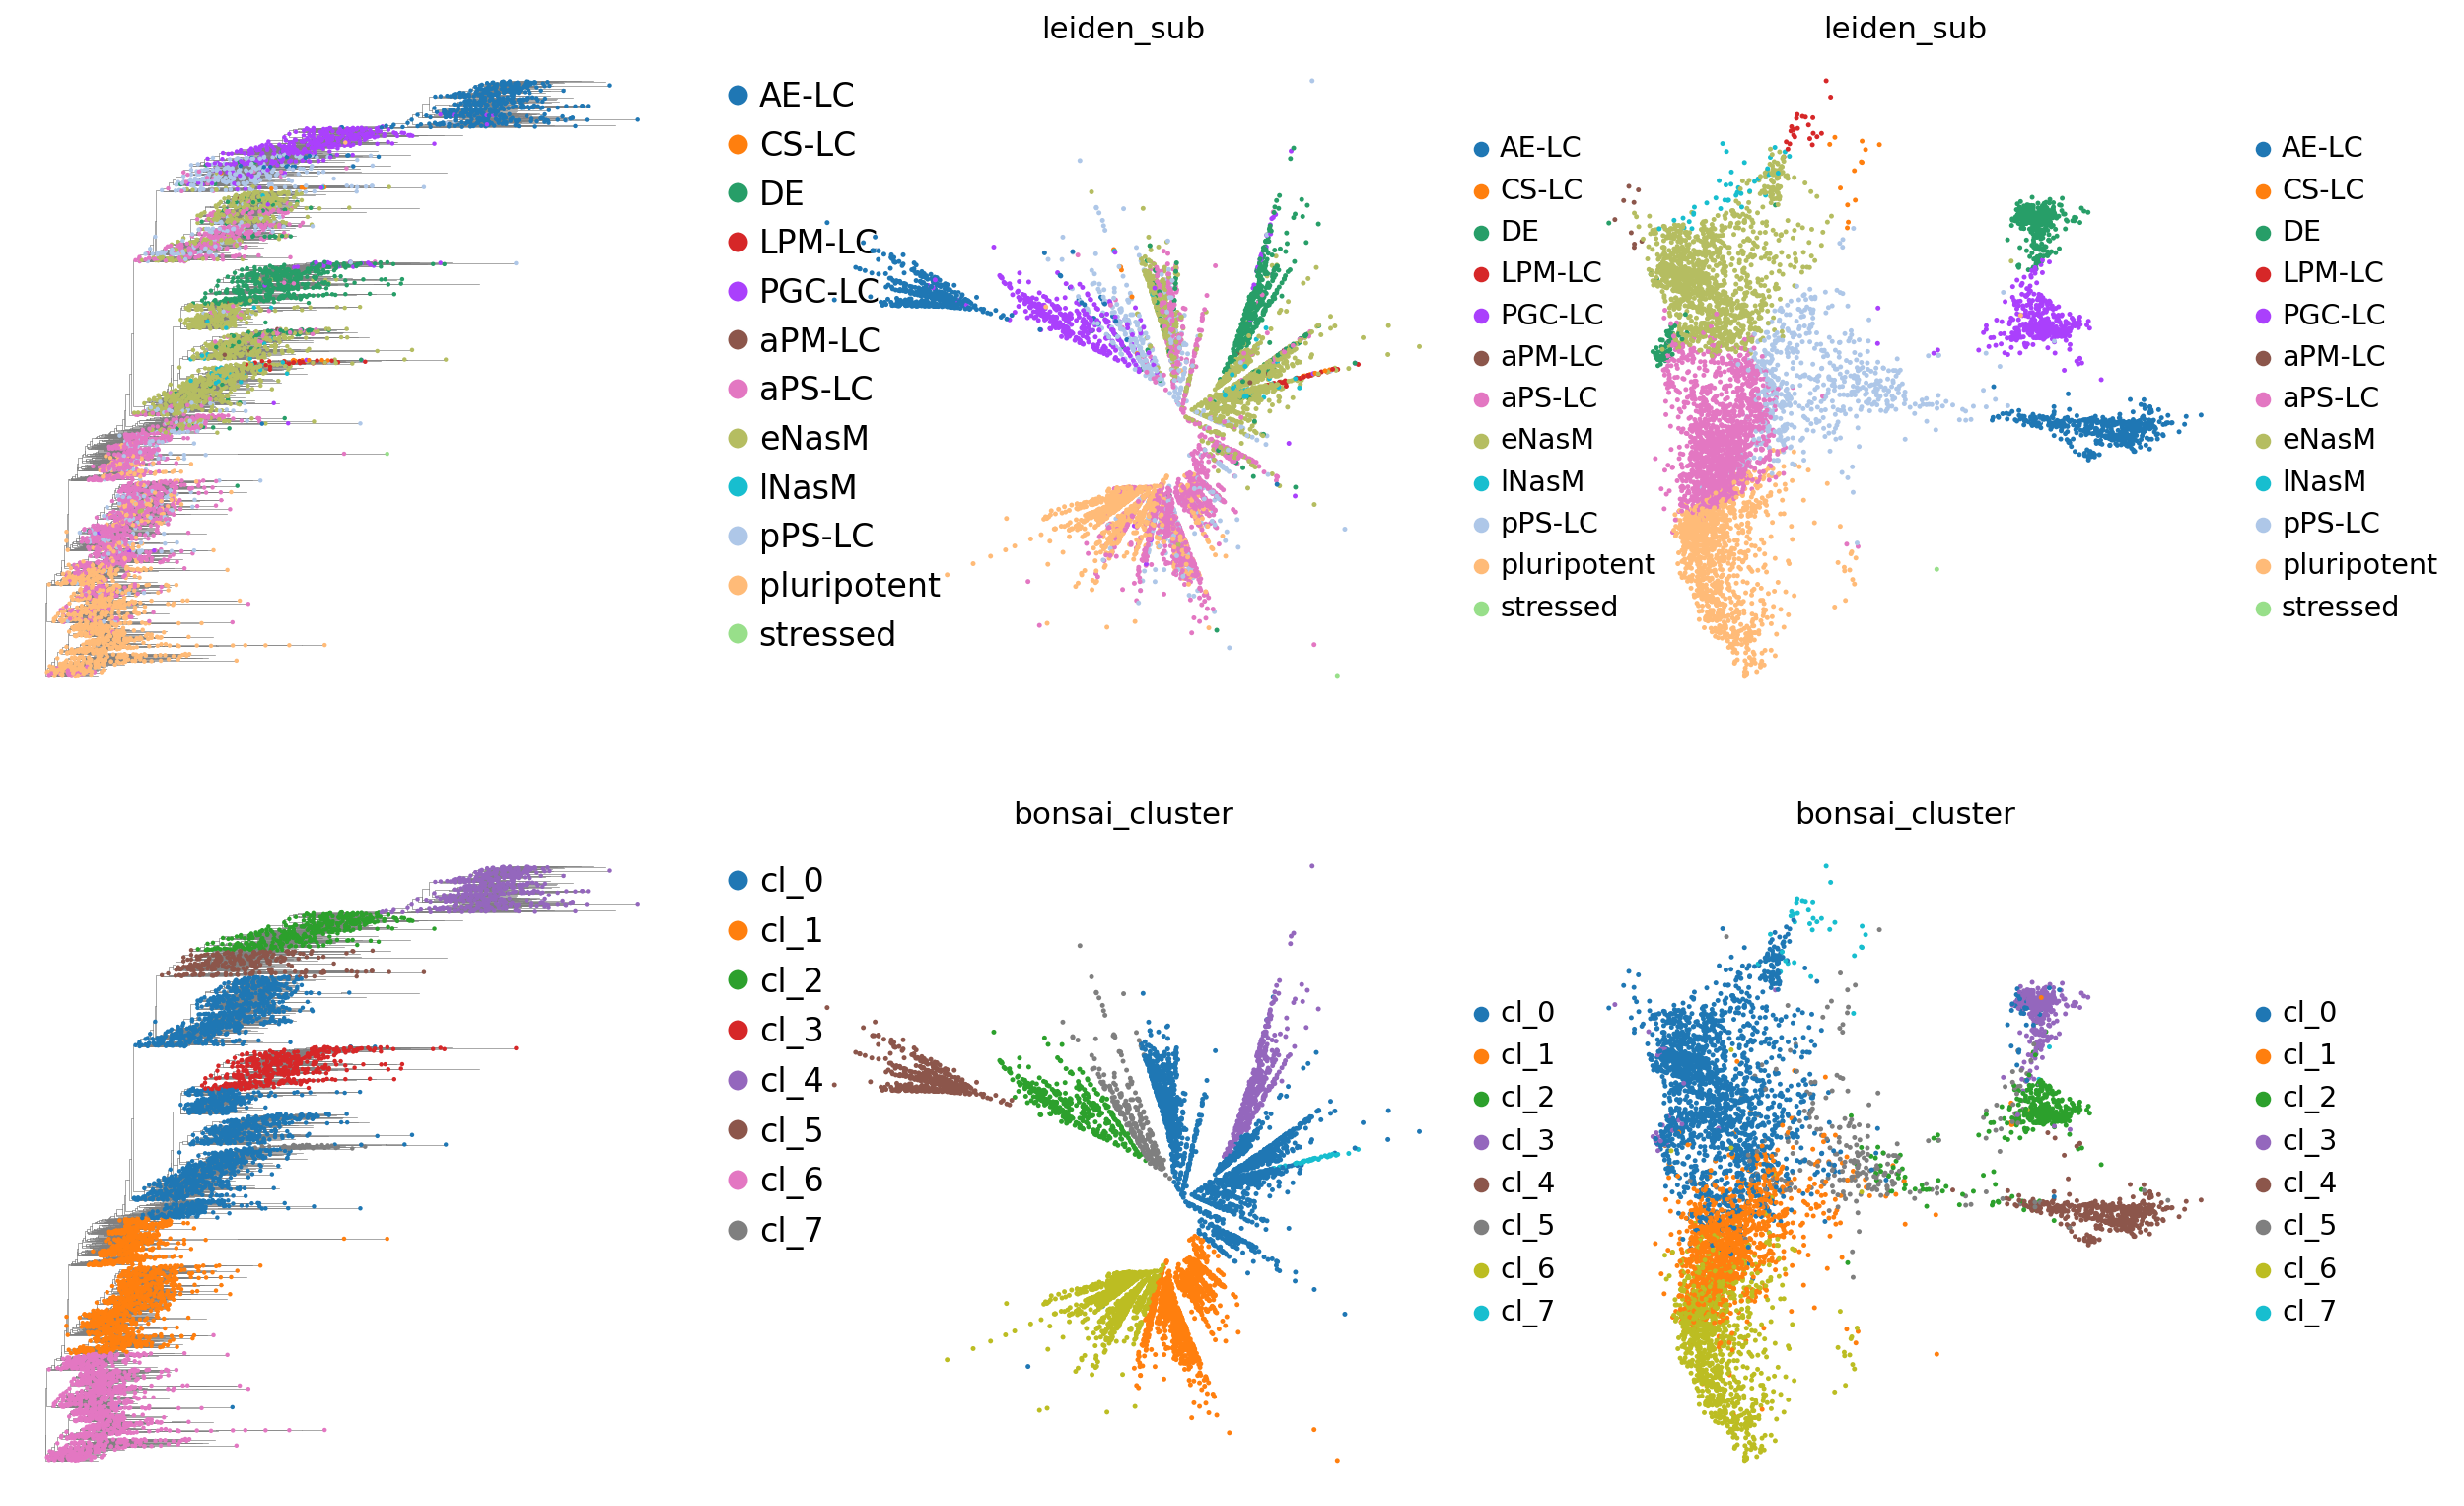

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(24 * 0.75, 16 * 0.75))
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

ax = axes[0, 0]

for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

ax = axes[1, 0]

categories_bc = adata.obs["bonsai_cluster"].cat.categories
palette = dict(zip(categories_bc, plt.cm.tab10.colors[: len(categories_bc)]))
cell_colors_bc = [palette[c] for c in adata.obs["bonsai_cluster"]]
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors_bc, zorder=3)
ax.set_aspect("auto")
handles_bc = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[c],
        markersize=10,
        label=c,
    )
    for c in categories_bc
]
ax.legend(
    handles=handles_bc,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

ax = axes[0, 1]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="leiden_sub",
    ax=ax,
    show=False,
    s=20,
    frameon=False,
)
ax = axes[1, 1]
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="bonsai_cluster",
    ax=ax,
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
ax = axes[0, 2]
sc.pl.umap(
    adata,
    color="leiden_sub",
    ax=ax,
    show=False,
    s=20,
    frameon=False,
)
ax = axes[1, 2]
sc.pl.umap(
    adata,
    color="bonsai_cluster",
    ax=ax,
    show=False,
    s=20,
    palette="tab10",
    frameon=False,
)
plt.savefig(
    "bonsai_micropattern_48h-1_summary_figure.png", dpi=300, bbox_inches="tight"
)